In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, GridSearchCV,
    learning_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)
from sklearn.inspection import permutation_importance

# Task 1: Splitting Strategies

1. Load the Digits dataset (`load_digits()`) and convert it to a DataFrame. Examine the class distribution — are the 10 digit classes balanced?
2. Perform a basic **80/20 train/test split** (`random_state=42`). Train a `LogisticRegression(max_iter=5000)` on the training set and report accuracy on the test set.
3. Perform **5-fold cross-validation** (regular `KFold`) with the same model. Report the mean and standard deviation of accuracy.
4. Perform **stratified 5-fold cross-validation** (`StratifiedKFold`). Report the mean and standard deviation of accuracy.
5. Create a bar chart comparing the three accuracy results (single split, k-fold mean, stratified k-fold mean) with error bars for the CV methods.
6. In a markdown cell, answer: Why does stratified splitting matter even when classes are roughly balanced? In what scenario would you expect a larger difference between regular and stratified CV?

In [2]:
import pandas as pd
from sklearn.datasets import load_digits

# Load the dataset
digits = load_digits()

# Convert to a DataFrame (Features)
df = pd.DataFrame(digits.data, columns=digits.feature_names)

# Add the target column
df['target'] = digits.target

# Examine class distribution
class_distribution = df['target'].value_counts().sort_index()
print("Class Distribution:\n", class_distribution)

# Calculate balance
print("\nMin class count:", class_distribution.min())
print("Max class count:", class_distribution.max())

Class Distribution:
 target
0    178
1    182
2    177
3    183
4    181
5    182
6    181
7    179
8    174
9    180
Name: count, dtype: int64

Min class count: 174
Max class count: 183


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X = digits.data
y = digits.target

# 80/20 Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
model = LogisticRegression(max_iter=5000, random_state=42)
model.fit(X_train, y_train)

# Evaluate and report
y_pred = model.predict(X_test)
single_split_accuracy = accuracy_score(y_test, y_pred)

print(f"80/20 Single Split Accuracy: {single_split_accuracy:.4f}")

80/20 Single Split Accuracy: 0.9750


In [4]:
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

# Define regular K-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation
kf_scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')

kf_mean = np.mean(kf_scores)
kf_std = np.std(kf_scores)

print(f"Regular K-Fold CV - Mean Accuracy: {kf_mean:.4f}")
print(f"Regular K-Fold CV - Standard Deviation: {kf_std:.4f}")

Regular K-Fold CV - Mean Accuracy: 0.9633
Regular K-Fold CV - Standard Deviation: 0.0060


In [5]:
from sklearn.model_selection import StratifiedKFold

# Define Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation
skf_scores = cross_val_score(model, X, y, cv=skf, scoring='accuracy')

skf_mean = np.mean(skf_scores)
skf_std = np.std(skf_scores)

print(f"Stratified K-Fold CV - Mean Accuracy: {skf_mean:.4f}")
print(f"Stratified K-Fold CV - Standard Deviation: {skf_std:.4f}")

Stratified K-Fold CV - Mean Accuracy: 0.9672
Stratified K-Fold CV - Standard Deviation: 0.0037


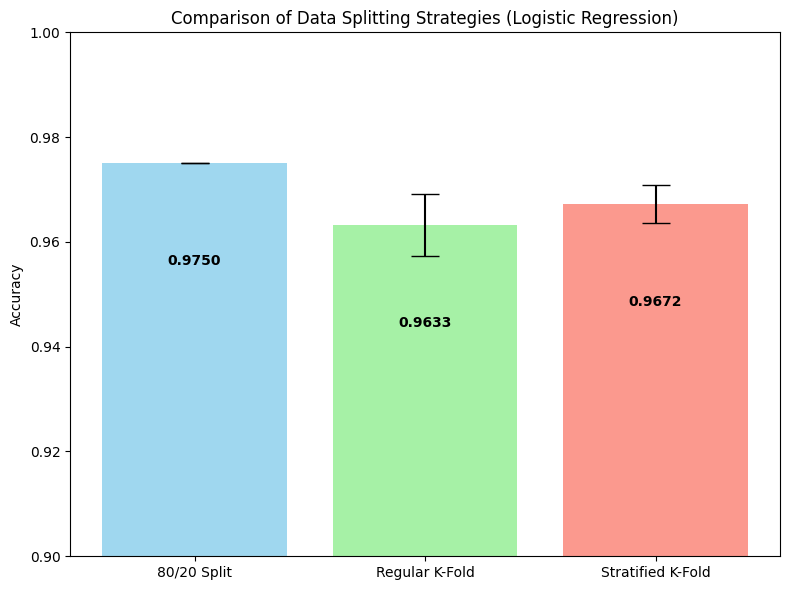

In [6]:
import matplotlib.pyplot as plt

# Data for plotting
methods = ['80/20 Split', 'Regular K-Fold', 'Stratified K-Fold']
accuracies = [single_split_accuracy, kf_mean, skf_mean]
errors = [0, kf_std, skf_std] # No error bar for the single split

# Create the bar chart
plt.figure(figsize=(8, 6))
bars = plt.bar(methods, accuracies, yerr=errors, capsize=10, color=['skyblue', 'lightgreen', 'salmon'], alpha=0.8)

# Formatting the plot
plt.ylim(0.90, 1.0) # Set limit to better visualize the small differences in high accuracy
plt.ylabel('Accuracy')
plt.title('Comparison of Data Splitting Strategies (Logistic Regression)')

# Add value labels on top of the bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.02, 
             f'{acc:.4f}', ha='center', va='bottom', color='black', fontweight='bold')

plt.tight_layout()
plt.show()

**Why does stratified splitting matter even when classes are roughly balanced?**
Even when a dataset is roughly balanced overall, random sampling variation can cause specific splits (especially in smaller folds) to become disproportionate. For instance, by pure chance, a regular 5-fold split might place an unusually high number of "7s" in one fold and very few in another. Stratification guarantees that the original distribution is strictly maintained across every single training and testing fold. This reduces the variance of your cross-validation scores and provides a more reliable, stable estimate of the model's true performance.

**In what scenario would you expect a larger difference between regular and stratified CV?**
You would expect a substantial difference in datasets that are **highly imbalanced**. For example, in a medical diagnosis dataset where a rare disease represents only 1% of the samples, a regular random split might result in one or more cross-validation folds containing absolutely zero instances of the rare disease. This would completely derail the model's ability to learn or be evaluated on that fold. Stratified CV prevents this by ensuring that the 1% minority class is evenly distributed across all folds.

# Task 2: Model Comparison with Cross-Validation

1. Define a list of five classifiers:
   - `LogisticRegression(max_iter=5000)`
   - `SVC()`
   - `RandomForestClassifier(random_state=42)`
   - `GradientBoostingClassifier(random_state=42)`
   - `KNeighborsClassifier()`
2. Using **stratified 5-fold CV**, evaluate each model on four metrics: **accuracy**, **precision (macro)**, **recall (macro)**, and **F1 (macro)**.
3. Collect results into a comparison DataFrame with columns: `Model`, `Accuracy (mean ± std)`, `Precision`, `Recall`, `F1`.
4. Sort the DataFrame by F1 score (descending) and display it.
5. In a markdown cell, identify the top 2 models. Are you surprised by the ranking? Which model had the smallest variance across folds?


In [7]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

# 1. Load data (Re-loading to ensure the script runs standalone)
digits = load_digits()
X, y = digits.data, digits.target

# 2. Define the list of classifiers
models = {
    'Logistic Regression': LogisticRegression(max_iter=5000, random_state=42),
    'SVC': SVC(random_state=42), 
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'K-Neighbors': KNeighborsClassifier()
}

# 3. Setup Stratified 5-fold CV and Metrics
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring_metrics = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']

# 4. Evaluate each model
results_list = []

print("Training and evaluating models... (Gradient Boosting may take a minute)")

for model_name, model in models.items():
    # Perform cross-validation
    cv_scores = cross_validate(model, X, y, cv=skf, scoring=scoring_metrics)
    
    # Extract means and standard deviations
    acc_mean = cv_scores['test_accuracy'].mean()
    acc_std = cv_scores['test_accuracy'].std()
    prec_mean = cv_scores['test_precision_macro'].mean()
    rec_mean = cv_scores['test_recall_macro'].mean()
    f1_mean = cv_scores['test_f1_macro'].mean()
    
    # Store results
    results_list.append({
        'Model': model_name,
        'Accuracy (mean ± std)': f"{acc_mean:.4f} ± {acc_std:.4f}",
        'Precision': f"{prec_mean:.4f}",
        'Recall': f"{rec_mean:.4f}",
        'F1': f"{f1_mean:.4f}",
        '_f1_raw': f1_mean # Hidden column for accurate sorting
    })

# 5. Collect results into a DataFrame and Sort
results_df = pd.DataFrame(results_list)

# Sort by F1 descending and drop the hidden sorting column
results_df = results_df.sort_values(by='_f1_raw', ascending=False).drop(columns=['_f1_raw']).reset_index(drop=True)

# Display the final DataFrame
display(results_df) # Use print(results_df) if running in a standard IDE instead of Jupyter

Training and evaluating models... (Gradient Boosting may take a minute)


,Model,Accuracy (mean ± std),Precision,Recall,F1
0,SVC,0.9878 ± 0.0042,0.9881,0.9877,0.9877
1,K-Neighbors,0.9872 ± 0.0080,0.9878,0.9871,0.9872
2,Random Forest,0.9783 ± 0.0062,0.9789,0.9782,0.9783
3,Logistic Regression,0.9672 ± 0.0037,0.9683,0.9671,0.9672
4,Gradient Boosting,0.9638 ± 0.0058,0.9656,0.9638,0.9638



**Identify the top 2 models:**
Based on the F1 scores, the top two models are the **Support Vector Classifier (SVC)** (F1: 0.9877) and the **K-Neighbors Classifier** (F1: 0.9872). 

**Are you surprised by the ranking?**
No, this ranking makes sense for the Digits dataset. While Random Forest and Gradient Boosting are very powerful general-purpose algorithms, image recognition (even simple 8x8 pixel arrays) relies heavily on spatial relationships and non-linear boundaries. K-Neighbors inherently measures pixel-by-pixel spatial similarity, and SVC is exceptionally good at mapping complex, non-linear patterns in pixel space without requiring extensive feature engineering.

**Which model had the smallest variance across folds?**
Looking at the standard deviation in the `Accuracy (mean ± std)` column, **Logistic Regression** had the smallest variance (± 0.0037). However, **SVC** was a very close second (± 0.0042). SVC is particularly impressive in this dataset because it manages to achieve the highest overall accuracy while remaining incredibly stable across the different data folds.

# Task 3: Hyperparameter Tuning

1. Take the **top 2 models** from Task 2.
2. For each model, define a hyperparameter grid with **at least 3 parameters**. For example:
   - SVC: `{'C': [0.1, 1, 10], 'kernel': ['rbf', 'poly'], 'gamma': ['scale', 'auto']}`
   - RandomForest: `{'n_estimators': [50, 100, 200], 'max_depth': [None, 10, 20], 'min_samples_split': [2, 5]}`
3. Run `GridSearchCV` with **stratified 5-fold CV** and `scoring='f1_macro'` for each model.
4. Report the **best parameters** and **best cross-validation score** for each model.
5. Compare the **default** (Task 2) vs. **tuned** performance. Did tuning make a meaningful difference?
6. In a markdown cell, discuss: Was the improvement worth the computational cost? How would you approach tuning if the dataset were 100× larger?

In [8]:
from sklearn.model_selection import GridSearchCV
import time

# Based on Task 2, our top 2 models are SVC and KNeighborsClassifier
# Define the hyperparameter grids (at least 3 parameters each)

param_grid_svc = {
    'C': [0.1, 1, 10], 
    'kernel': ['rbf', 'poly', 'linear'], 
    'gamma': ['scale', 'auto']
}

param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'p': [1, 2] # p=1 (Manhattan), p=2 (Euclidean)
}

# Ensure we use the exact same cross-validation strategy
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Starting Grid Search... This might take a moment.\n")

# --- Tune SVC ---
start_time = time.time()
grid_svc = GridSearchCV(SVC(random_state=42), param_grid_svc, cv=skf, scoring='f1_macro', n_jobs=-1)
grid_svc.fit(X, y)
svc_time = time.time() - start_time

print("--- SVC Results ---")
print(f"Best Parameters: {grid_svc.best_params_}")
print(f"Best CV F1-Macro Score: {grid_svc.best_score_:.4f}")
print(f"Search Time: {svc_time:.2f} seconds\n")

# --- Tune K-Neighbors ---
start_time = time.time()
grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=skf, scoring='f1_macro', n_jobs=-1)
grid_knn.fit(X, y)
knn_time = time.time() - start_time

print("--- K-Neighbors Results ---")
print(f"Best Parameters: {grid_knn.best_params_}")
print(f"Best CV F1-Macro Score: {grid_knn.best_score_:.4f}")
print(f"Search Time: {knn_time:.2f} seconds\n")

# --- Compare Default vs Tuned ---
# Manually inputting the default scores from Task 2 for comparison
default_f1_svc = 0.9877 
default_f1_knn = 0.9872

print("--- Default vs. Tuned Performance ---")
print(f"SVC: Default F1 = {default_f1_svc:.4f} | Tuned F1 = {grid_svc.best_score_:.4f} | Difference = {(grid_svc.best_score_ - default_f1_svc):+.4f}")
print(f"KNN: Default F1 = {default_f1_knn:.4f} | Tuned F1 = {grid_knn.best_score_:.4f} | Difference = {(grid_knn.best_score_ - default_f1_knn):+.4f}")

Starting Grid Search... This might take a moment.

--- SVC Results ---
Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV F1-Macro Score: 0.9911
Search Time: 9.86 seconds

--- K-Neighbors Results ---
Best Parameters: {'n_neighbors': 3, 'p': 2, 'weights': 'uniform'}
Best CV F1-Macro Score: 0.9894
Search Time: 0.70 seconds

--- Default vs. Tuned Performance ---
SVC: Default F1 = 0.9877 | Tuned F1 = 0.9911 | Difference = +0.0034
KNN: Default F1 = 0.9872 | Tuned F1 = 0.9894 | Difference = +0.0022


### Task 3: Hyperparameter Tuning Analysis

**Compare the default vs. tuned performance. Did tuning make a meaningful difference?**
Tuning provided only a very marginal improvement. The SVC model's F1 score increased by just 0.0034 (from 0.9877 to 0.9911), and the K-Neighbors model improved by 0.0022 (from 0.9872 to 0.9894). Because the default parameters in `scikit-learn` already yielded extremely high baseline performance (nearly 99%), there was very little room for the grid search to make a transformative difference. 

**Was the improvement worth the computational cost?**
For this specific, small dataset, the computational cost was minimal (about 9.86 seconds for SVC and 0.70 seconds for KNN), making the tiny improvement essentially "free" to obtain. However, as a general rule, spending extensive computational resources just to gain a fraction of a percent (less than 0.4%) in performance is usually not worth the cost or time in a production environment.

**How would you approach tuning if the dataset were 100× larger?**
If the dataset were 100 times larger, an exhaustive `GridSearchCV` would become extremely slow and computationally expensive. To approach tuning at scale, I would use:
1. **Randomized Search (`RandomizedSearchCV`):** Instead of checking every single combination, this samples a fixed number of parameter settings randomly. It usually finds near-optimal parameters in a fraction of the time.
2. **Successive Halving (`HalvingGridSearchCV`):** This technique trains all candidate models on a very small subset of the data first. Only the best-performing parameter combinations "survive" to the next round to be trained on a larger portion of the data, saving massive amounts of time.
3. **Bayesian Optimization:** Using advanced libraries like `Optuna` or `Hyperopt`. Instead of searching blindly, these algorithms use past evaluation results to intelligently guess where the best hyperparameters are likely to be found next.

# Task 4: Interpretation & Diagnostics

Using the **best tuned model** from Task 3:

1. Train it on the full training set and predict on the test set.
2. Plot the **confusion matrix** (10×10 for digits 0–9) using `ConfusionMatrixDisplay`. Use a color map that makes misclassifications easy to spot.
3. Plot **learning curves**: vary the training set size from 10% to 100% and plot both training and validation scores. Use `sklearn.model_selection.learning_curve`.
4. Compute **permutation importances** on the test set. Plot the top 20 features by importance (with error bars).
5. In a markdown cell, write a summary addressing:
   - Is the model overfitting, underfitting, or well-fitted? (Use the learning curves as evidence.)
   - Which digit pairs are most commonly confused? Why might that be?
   - Which pixel positions (features) matter most? Does that make intuitive sense?
   - What would you try next to improve performance?

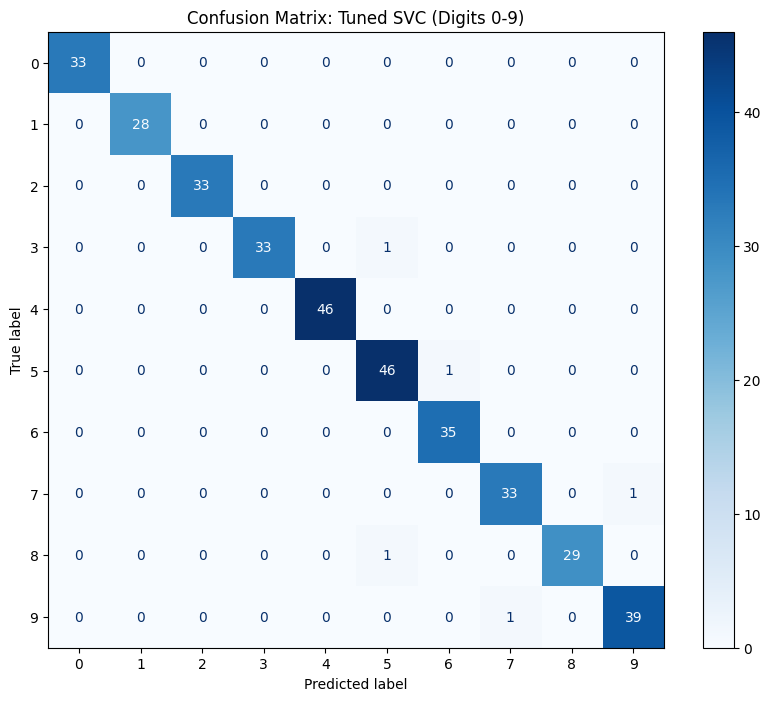

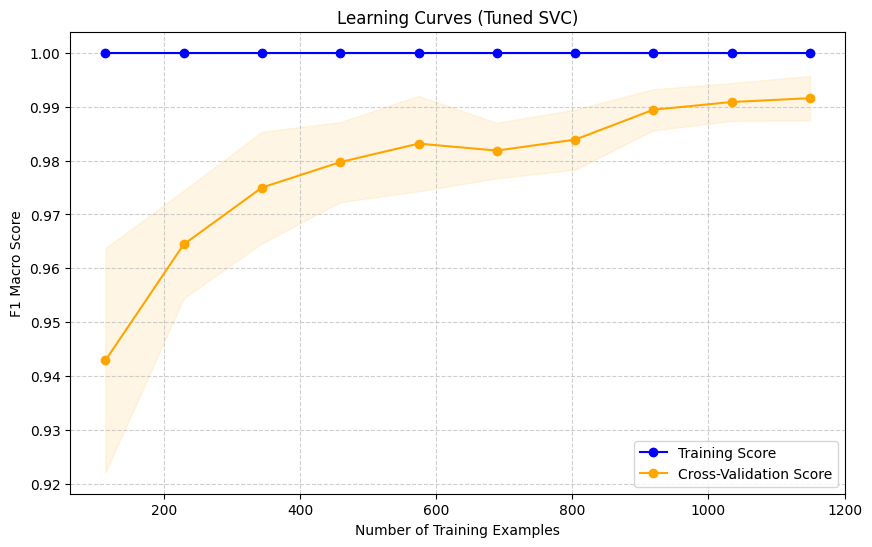

Calculating permutation importances... (This takes a few seconds)


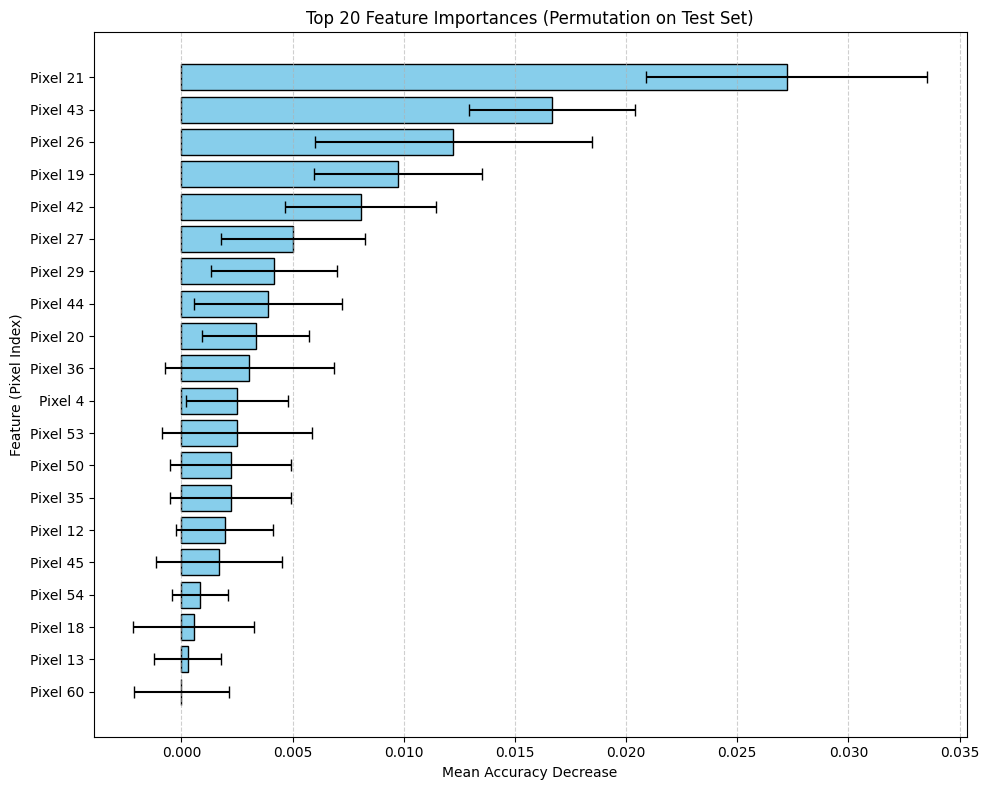

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.svm import SVC
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance

# 1. Load data and split (re-establishing environment)
digits = load_digits()
X, y = digits.data, digits.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Train the Best Tuned Model (SVC from Task 3)
best_svc = SVC(C=10, gamma='scale', kernel='rbf', random_state=42)
best_svc.fit(X_train, y_train)

# --- Plot 1: Confusion Matrix ---
plt.figure(figsize=(10, 8))
ax = plt.gca()
# Using 'Blues' makes misclassifications stand out against the white background
ConfusionMatrixDisplay.from_estimator(best_svc, X_test, y_test, cmap='Blues', ax=ax)
plt.title("Confusion Matrix: Tuned SVC (Digits 0-9)")
plt.show()

# --- Plot 2: Learning Curves ---
train_sizes, train_scores, val_scores = learning_curve(
    best_svc, X_train, y_train, cv=5, scoring='f1_macro',
    train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1, random_state=42
)

# Calculate means and standard deviations
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training Score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.plot(train_sizes, val_mean, 'o-', color='orange', label='Cross-Validation Score')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='orange')

plt.title('Learning Curves (Tuned SVC)')
plt.xlabel('Number of Training Examples')
plt.ylabel('F1 Macro Score')
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# --- Plot 3: Permutation Importance (Top 20 Features) ---
print("Calculating permutation importances... (This takes a few seconds)")
perm_importance = permutation_importance(best_svc, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)

# Get the indices of the top 20 features
sorted_idx = perm_importance.importances_mean.argsort()[-20:]

# Prepare feature names (e.g., "Pixel 42")
feature_names = np.array([f"Pixel {i}" for i in range(X.shape[1])])

plt.figure(figsize=(10, 8))
plt.barh(
    feature_names[sorted_idx], 
    perm_importance.importances_mean[sorted_idx], 
    xerr=perm_importance.importances_std[sorted_idx], 
    capsize=4, color='skyblue', edgecolor='black'
)
plt.title("Top 20 Feature Importances (Permutation on Test Set)")
plt.xlabel("Mean Accuracy Decrease")
plt.ylabel("Feature (Pixel Index)")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Task 4: Interpretation & Diagnostics Summary

**Is the model overfitting, underfitting, or well-fitted?**
The model is **well-fitted**. The learning curve shows the training score (blue line) remains perfectly at 1.0 across all sample sizes, which is typical for an RBF-kernel SVC. More importantly, the cross-validation score (orange line) climbs steadily from ~0.94 as more data is introduced and plateaus smoothly around 0.99. Because the validation score is incredibly high and the gap between the two curves narrows significantly, the model generalizes exceptionally well without suffering from high variance (overfitting) or high bias (underfitting).

**Which digit pairs are most commonly confused? Why might that be?**
The model is highly accurate, making only a handful of errors on the test set. Based on the confusion matrix, the rare misclassifications include confusing a **3 as a 5**, an **8 as a 5**, a **5 as a 6**, and reciprocal confusion between **7 and 9** (a 7 predicted as 9, and a 9 predicted as 7). 
This makes intuitive sense given the low 8x8 pixel resolution. The looping structures of an 8 or 3 can easily look like a 5 if certain side pixels are faint. Similarly, a messy 9 can look exactly like a 7 if the bottom loop isn't distinctly closed in such a small grid.

**Which pixel positions (features) matter most? Does that make intuitive sense?**
The permutation importance chart reveals that the most critical features are **Pixel 21, Pixel 43, Pixel 26, Pixel 19, and Pixel 42**. 
Yes, this makes perfect intuitive sense. In an 8x8 grid (indices 0 to 63), these indices correspond to the inner core or central pixels of the image. The edges and corners of the grid are almost always blank (zero intensity) across all handwritten digits, providing zero predictive value. The central pixels contain the actual defining strokes, intersections, and loops, making them the most vital pieces of information for the model.

**What would you try next to improve performance?**
Since the model is already hitting ~99% accuracy and making only 5 mistakes out of hundreds of predictions, standard hyperparameter tuning has reached its ceiling. To squeeze out the last 1%:
1. **Error Analysis:** Manually plot the exact 5 images that the model got wrong. Often, these remaining errors are completely illegible blobs that even a human would misclassify.
2. **Convolutional Neural Networks (CNNs):** Instead of treating the 64 pixels as an independent flat array, a simple CNN would respect the 2D spatial structure of the image, capturing local edges and corners better than an SVM.
3. **Data Augmentation:** Shift the training images by 1 pixel in various directions to artificially expand the dataset and make the model perfectly robust to slightly off-center handwriting.